# Train Conditional Transformer

Dataset: `data/data.txt`. Saves the best checkpoint by validation joint compliance.

**Reproducibility:** `seed=42` set in every entry point.


In [1]:
# Colab bootstrap: clone the repo if we're on Colab, set the cwd.
import os, sys, subprocess, pathlib
REPO_URL = 'https://github.com/a7mdka7la/GAN-AI-project.git'
REPO_DIR = pathlib.Path("/content/Assignment2")
if "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ:
    if not REPO_DIR.exists():
        # If the user has already uploaded the zip, prefer that.
        zip_path = pathlib.Path("/content/Assignment2.zip")
        if zip_path.exists():
            subprocess.run(["unzip", "-q", str(zip_path), "-d", "/content"], check=True)
        else:
            subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(str(REPO_DIR))
else:
    # Local: cd to the repo (this notebooks/ dir's parent).
    os.chdir(str(pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()))
sys.path.insert(0, os.getcwd())
print("cwd =", os.getcwd())
print("files:", os.listdir(".")[:10])


cwd = /content/Assignment2
files: ['.gitignore', '.git', 'README.md', 'environment.yml', 'notebooks', 'model', 'PLAN.md', 'data', 'tests', 'report']


## Train

In [2]:
# Train. epochs/batch_size can be raised if you have Colab time budget.
from model.transformer.train import train

best_path = train(
    data_path="data/data.txt",
    out_dir="runs/transformer",
    epochs=60,
    batch_size=1024,
    device="cuda",
    seed=42,
)
print("Best checkpoint:", best_path)


[transformer] ep 00 loss=8.5594 val_joint=0.1497 val_dow=0.1497 *
[transformer] ep 01 loss=5.3508 val_joint=0.1384 val_dow=0.1384
[transformer] ep 02 loss=5.2944 val_joint=0.1462 val_dow=0.1462
[transformer] ep 03 loss=5.2706 val_joint=0.1489 val_dow=0.1489
[transformer] ep 04 loss=5.2514 val_joint=0.1414 val_dow=0.1414
[transformer] ep 05 loss=5.2360 val_joint=0.1365 val_dow=0.1365
[transformer] ep 06 loss=5.2249 val_joint=0.1414 val_dow=0.1414
[transformer] ep 07 loss=5.2138 val_joint=0.1580 val_dow=0.1580 *
[transformer] ep 08 loss=5.2021 val_joint=0.1592 val_dow=0.1592 *
[transformer] ep 09 loss=5.1681 val_joint=0.1523 val_dow=0.1523
[transformer] ep 10 loss=5.1131 val_joint=0.1663 val_dow=0.1663 *
[transformer] ep 11 loss=5.0169 val_joint=0.1743 val_dow=0.1743 *
[transformer] ep 12 loss=4.8384 val_joint=0.1934 val_dow=0.1934 *
[transformer] ep 13 loss=4.5668 val_joint=0.1982 val_dow=0.1982 *
[transformer] ep 14 loss=4.2508 val_joint=0.2261 val_dow=0.2261 *
[transformer] ep 15 loss

## Promote checkpoint

In [3]:
# Promote the best checkpoint to the location predict.py expects.
import shutil, pathlib
src = pathlib.Path("runs/transformer/transformer_best.pt")
dst = pathlib.Path("model/weights/transformer.pt")
dst.parent.mkdir(parents=True, exist_ok=True)
shutil.copy(src, dst)
print(f"Copied {src} -> {dst}")


Copied runs/transformer/transformer_best.pt -> model/weights/transformer.pt


## Quick smoke-evaluation on example_input.txt

In [4]:
# Quick smoke-eval on example_input.txt
import subprocess, sys
out = subprocess.run(
    [sys.executable, "-m", "model.evaluate",
     "--input", "data/example_input.txt", "--model", "transformer"],
    capture_output=True, text=True,
)
print(out.stdout)
if out.returncode != 0:
    print("STDERR:", out.stderr, file=sys.stderr)


n                       : 1465
validity (in-range, legal): 1.0000
acc_dow  (day-of-week)  : 0.3263
acc_month               : 1.0000
acc_leap                : 1.0000
acc_decade              : 1.0000
acc_joint (all 4 + valid): 0.3263
diversity entropy (mean): 2.0282



## Training/validation curves

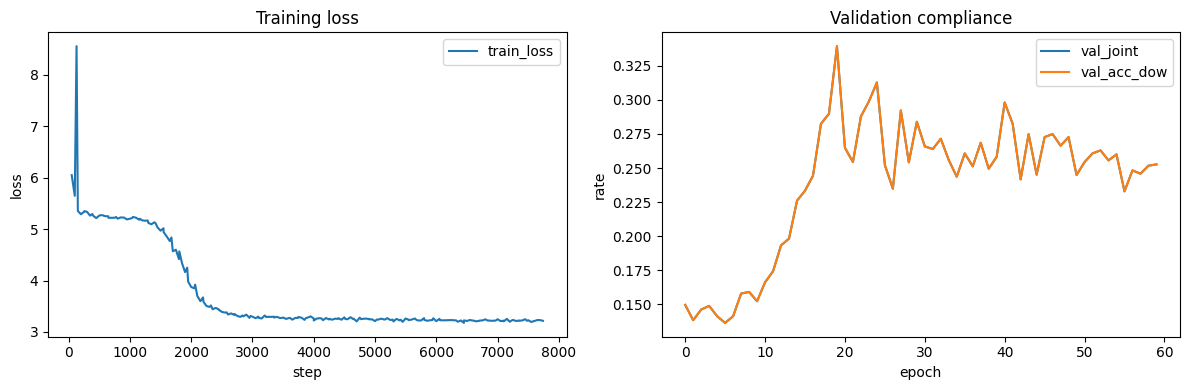

In [5]:
# Plot training loss + val joint compliance.
import json, matplotlib.pyplot as plt, pathlib
rows = [json.loads(l) for l in pathlib.Path("runs/transformer/log.jsonl").read_text().splitlines() if l.strip()]
ep_rows = [r for r in rows if r.get("val_joint_compliance") is not None]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot([r["step"] for r in rows], [r["train_loss"] for r in rows], label="train_loss")
ax[0].set_xlabel("step"); ax[0].set_ylabel("loss"); ax[0].set_title("Training loss"); ax[0].legend()
ax[1].plot([r["epoch"] for r in ep_rows], [r["val_joint_compliance"] for r in ep_rows], label="val_joint")
ax[1].plot([r["epoch"] for r in ep_rows], [r["val_acc_dow"] for r in ep_rows], label="val_acc_dow")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("rate"); ax[1].set_title("Validation compliance"); ax[1].legend()
plt.tight_layout(); plt.show()
